---
## Part 5: Comparative Exploration

**Goal:** Study differences across groups, time periods, or conditions.

### Exercise 5.1: Mortality Rate Comparison

1. Calculate the overall mortality rate (percentage with deceased='Y')
2. Compare mortality rates by visit type (Inpatient vs Outpatient)
3. Compare mortality rates by age group

In [ ]:
# 1. Overall mortality rate
# YOUR CODE HERE
df['deceased'].unique()

array(['Y', 'N'], dtype=object)

In [ ]:
overall_mortality_rate = (
    (df['deceased'] == 'Y').mean() * 100
)

overall_mortality_rate

np.float64(10.518554612366323)

In [ ]:
# 2. Mortality by visit type
# YOUR CODE HERE
# Hint: Use pd.crosstab() with normalize='index'
# Mortality by visit type (percent)
mortality_by_visit_type = (
    pd.crosstab(
        df['visit_type'],
        df['deceased'],
        normalize='index'
    ) * 100
)

mortality_by_visit_type

deceased,N,Y
visit_type,,
Emergency Room Visit,100.000000,0.000000
Inpatient Visit,69.763787,30.236213
Outpatient Visit,92.547831,7.452169


In [ ]:
# 3. Mortality by age group
# First ensure age_group exists
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age_at_visit_years'],
                             bins=[0, 18, 40, 65, 100],
                             labels=['Pediatric', 'Young Adult', 'Middle Age', 'Elderly'])

# YOUR CODE HERE
# Mortality by age group (percent)
mortality_by_age_group = (
    pd.crosstab(
        df['age_group'],
        df['deceased'],
        normalize='index'
    ) * 100
)

mortality_by_age_group

deceased,N,Y
age_group,,
Pediatric,98.130446,1.869554
Young Adult,91.818896,8.181104
Middle Age,84.341614,15.658386
Elderly,80.992564,19.007436


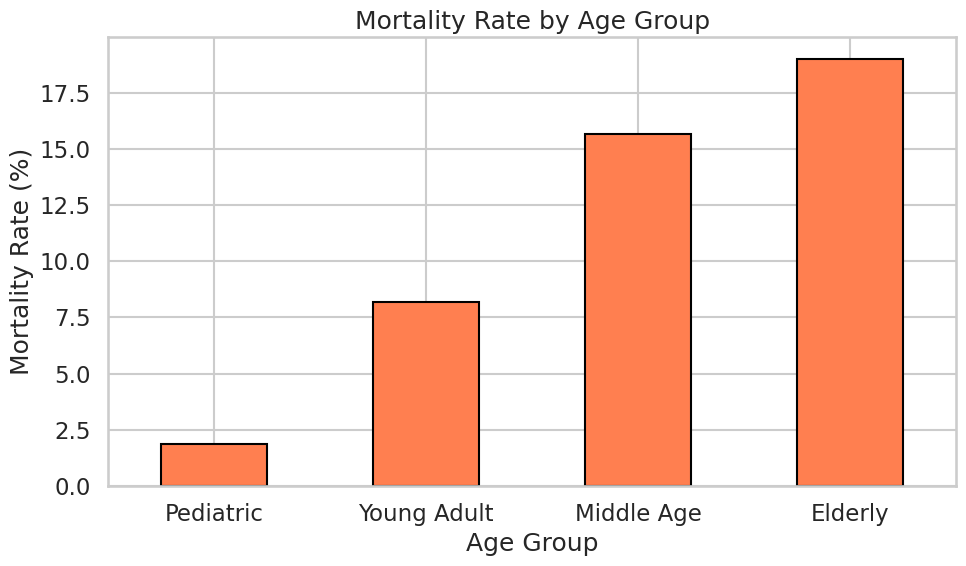

In [ ]:
# Visualization
mortality_by_age_group['Y'].plot(kind='bar', figsize=(10, 6), color='coral', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate (%)')
plt.title('Mortality Rate by Age Group')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Exercise 5.2: Visit Type by Age Group

Create a cross-tabulation showing what percentage of each age group has Inpatient vs Outpatient visits.

In [ ]:
# YOUR CODE HERE
# Percentage of visit type within each age group
age_group_visit_type_pct = (
    pd.crosstab(
        df['age_group'],
        df['visit_type'],
        normalize='index'
    ) * 100
)

age_group_visit_type_pct

visit_type,Emergency Room Visit,Inpatient Visit,Outpatient Visit
age_group,,,
Pediatric,0.023487,2.388614,97.587900
Young Adult,0.014290,10.274609,89.711101
Middle Age,0.006475,18.386463,81.607062
Elderly,0.004177,28.243796,71.752026


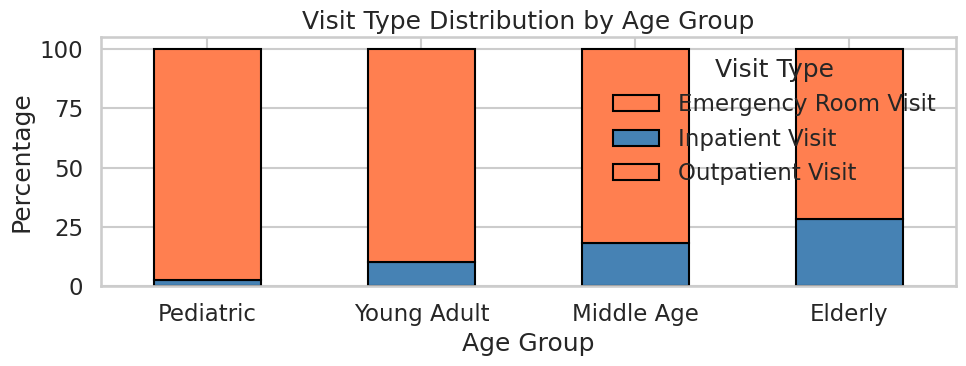

In [ ]:
# Stacked bar chart
age_group_visit_type_pct.plot(kind='bar', stacked=True, figsize=(10, 4),
                  color=['coral', 'steelblue'], edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.title('Visit Type Distribution by Age Group')
plt.legend(title='Visit Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Exercise 5.3: COVID vs Non-COVID Comparison

Compare characteristics between COVID-suspected and non-COVID visits:
1. Average age
2. Visit type distribution
3. Mortality rate

In [ ]:
# Create a COVID indicator
df['is_covid_suspected'] = df['observation_source'] == 'Suspected COVID-19'

# YOUR CODE HERE - compare the groups
avg_age_by_covid = (
    df
    .groupby('is_covid_suspected')['age_at_visit_years']
    .mean()
)

avg_age_by_covid

,age_at_visit_years
is_covid_suspected,
False,34.601800
True,41.528952


In [ ]:
visit_type_dist_by_covid = (
    pd.crosstab(
        df['is_covid_suspected'],
        df['visit_type'],
        normalize='index'
    ) * 100
)

visit_type_dist_by_covid

visit_type,Emergency Room Visit,Inpatient Visit,Outpatient Visit
is_covid_suspected,,,
False,0.02419,5.483926,94.491884
True,0.00000,22.462957,77.537043


In [ ]:
mortality_by_covid = (
    pd.crosstab(
        df['is_covid_suspected'],
        df['deceased'],
        normalize='index'
    ) * 100
)

mortality_by_covid

deceased,N,Y
is_covid_suspected,,
False,99.57788,0.42212
True,78.09234,21.90766


### Exercise 5.4: Statistical Significance Testing

Test whether the difference in oxygen saturation between deceased and non-deceased patients is statistically significant.

1. State your null hypothesis
2. Perform a Mann-Whitney U test (non-parametric alternative to t-test)
3. Interpret the results

In [ ]:
# Separate the two groups
deceased_o2 = covid_df[covid_df['deceased'] == 'Y']['oxygen_saturation_percent'].dropna()
survived_o2 = covid_df[covid_df['deceased'] == 'N']['oxygen_saturation_percent'].dropna()

print(f"Deceased - Mean: {deceased_o2.mean():.2f}, Median: {deceased_o2.median():.2f}, n={len(deceased_o2)}")
print(f"Survived - Mean: {survived_o2.mean():.2f}, Median: {survived_o2.median():.2f}, n={len(survived_o2)}")

Deceased - Mean: 81.97, Median: 81.90, n=16056
Survived - Mean: 82.02, Median: 82.00, n=57224


In [ ]:
# Perform Mann-Whitney U test
# YOUR CODE HERE
# Hint: Use stats.mannwhitneyu()
from scipy import stats

u_stat, p_value = stats.mannwhitneyu(
    deceased_o2,
    survived_o2,
    alternative='two-sided'
)

print(f"Mann-Whitney U statistic: {u_stat}")
print(f"P-value: {p_value}")

Mann-Whitney U statistic: 456528681.0
P-value: 0.22635693266555956


In [ ]:
if p_value < 0.05:
    print("Reject the null hypothesis: oxygen saturation differs significantly between deceased and non-deceased patients.")
else:
    print("Fail to reject the null hypothesis: no statistically significant difference detected.")

Fail to reject the null hypothesis: no statistically significant difference detected.


**Interpretation:** Based on the p-value, is the difference statistically significant at α = 0.05?

*Your answer here:*
No, the Mann-Whitney U test did not find a statistically significant difference in oxygen saturation between deceased and surviving patients


### Exercise 5.5: Condition-Specific Analysis

1. Identify which specific conditions are most associated with inpatient admission
2. Calculate the inpatient rate for each condition
3. Which conditions have the highest inpatient rates?

In [ ]:
df['condition_list']

,condition_list
0,"[Dyspnea, Pneumonia, Respiratory distress, Whe..."
1,[Viral sinusitis]
2,"[Sore throat symptom, Dyspnea, Wheezing]"
3,[Perennial allergic rhinitis]
4,[Cough]
...,...
156025,[Cough]
156026,[Viral sinusitis]
156027,"[Acute respiratory failure, Pneumonia, Respira..."
156028,[Viral sinusitis]


In [ ]:
# YOUR CODE HERE
# Hint: Explode the condition_list, merge with visit_type, then calculate rates
condition_df = (
    df[['visit_occurrence_id', 'visit_type', 'condition_list']]
    .explode('condition_list')
)

In [ ]:
# Clean up condition names
condition_df['condition_list'] = condition_df['condition_list'].str.strip()

condition_df.head()

,visit_occurrence_id,visit_type,condition_list
0,1,Inpatient Visit,Dyspnea
0,1,Inpatient Visit,Pneumonia
0,1,Inpatient Visit,Respiratory distress
0,1,Inpatient Visit,Wheezing
1,28,Outpatient Visit,Viral sinusitis


In [ ]:
condition_df['is_inpatient'] = condition_df['visit_type'] == 'Inpatient'

In [ ]:
inpatient_rate_by_condition = (
    condition_df
    .groupby('condition_list')
    .agg(
        inpatient_rate=('is_inpatient', 'mean'),
        total_visits=('is_inpatient', 'size')
    )
    .sort_values('inpatient_rate', ascending=False)
)
inpatient_rate_by_condition_pre = inpatient_rate_by_condition['inpatient_rate']
# Convert to percentage
inpatient_rate_by_condition['inpatient_rate'] *= 100

inpatient_rate_by_condition

,inpatient_rate,total_visits
condition_list,,
Acute bacterial sinusitis,0.0,939
Acute bronchitis,0.0,7096
Acute respiratory distress syndrome,0.0,2445
Acute respiratory failure,0.0,9124
Acute viral pharyngitis,0.0,8344
Asthma,0.0,199
Childhood asthma,0.0,1715
Chronic sinusitis,0.0,26760
Cough,0.0,63418
